### The following cells are modified from Ilya's Code to fit into our project

Category: Appliances

In [1]:
import os
import duckdb
import requests
import pandas as pd
from tqdm import tqdm
from pathlib import Path

In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
CATEGORY = "Appliances"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
REVIEWS_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL    = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"
REVIEWS_FILE = RAW_DATA_DIR / f"{CATEGORY}.jsonl.gz"
META_FILE    = RAW_DATA_DIR / f"meta_{CATEGORY}.jsonl.gz"
OUTPUT_FILE  = RAW_DATA_DIR / f"{CATEGORY}_merged.parquet"

In [3]:
print(os.listdir())
print(RAW_DATA_DIR)
print(REVIEWS_URL)

['milestone1_exploration.ipynb', 'project_eda_duckdb.ipynb', 'milestone1_exploration_harrison.ipynb']
../data/raw
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Appliances.jsonl.gz


### Initialize an in-memory DB connection

In [4]:
c2 = duckdb.connect()

Review data:
- keep `rating, title, text, parent_asin, helpful_vote` columns only while downloading data
- other columns seems useless

In [5]:
c2.execute(f"SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 5").df()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


Meta data
- Drop images and videos while downloading data since we can't process it through links.
- other columns seems useful

In [6]:
c2.execute(f"SELECT * FROM read_json_auto('{META_URL}') LIMIT 5").df()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Our Point of View on the Euhomy Ic...,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': '10 Eggs Egg Holder for Refrigerato...,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,[{'thumb': 'https://m.media-amazon.com/images/...,[],Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


### download data in parquet if it doesn't exist in the directory

In [7]:
review_data_file = f'{CATEGORY}_reviews_raw.parquet'
meta_data_file = f'{CATEGORY}_meta_raw.parquet'

if review_data_file not in os.listdir(RAW_DATA_DIR):
    print("Downloading Review Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
          COPY (SELECT rating, title, text, parent_asin, helpful_vote FROM read_json_auto('{REVIEWS_URL}'))
          TO '{RAW_DATA_DIR}/{review_data_file}'
          (FORMAT PARQUET, COMPRESSION ZSTD)
      """)
    print("Done")
else:
    print("Review data for {} already downloaded".format(CATEGORY))

Category: Appliances
Done


In [8]:
c2.execute(f"SELECT * FROM read_parquet('{RAW_DATA_DIR}/{review_data_file}') LIMIT 5").df()

,rating,title,text,parent_asin,helpful_vote
0,5.0,Work great,work great. use a new one every month,B01N0TQ0OH,0
1,5.0,excellent product,Little on the thin side,B07DD37QPZ,0
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",B082W3Z9YK,0
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,B078W2BJY8,0
4,5.0,Dryer parts,Easy to install got the product expected to re...,B08C9LPCQV,0


In [9]:
if meta_data_file not in os.listdir(RAW_DATA_DIR):
    print("Downloading Meta Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
    COPY (SELECT * EXCLUDE (images, videos) FROM read_json_auto('{META_URL}', union_by_name=true))
    TO '{RAW_DATA_DIR}/{meta_data_file}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Done")
else:
    print("Meta data for {} already downloaded".format(CATEGORY))


Category: Appliances
Done


In [10]:
c2.execute(f"SELECT * FROM read_parquet('{RAW_DATA_DIR}/{meta_data_file}') LIMIT 5").df()

,main_category,title,average_rating,rating_number,features,description,price,store,categories,details,parent_asin,bought_together
0,Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lb...",3.7,61,[【Quick Ice Making】This countertop ice machine...,[],NaN,ROVSUN,"[Appliances, Refrigerators, Freezers & Ice Mak...","{'Brand': '""ROVSUN""', 'Model Name': '""ICM-2005...",B08Z743RRD,None
1,Tools & Home Improvement,"HANSGO Egg Holder for Refrigerator, Deviled Eg...",4.2,75,"[Plastic, Practical Kitchen Storage - Our egg ...",[],NaN,HANSGO,"[Appliances, Parts & Accessories, Refrigerator...","{'Manufacturer': '""HANSGO""', 'Part Number': '""...",B097BQDGHJ,None
2,Tools & Home Improvement,"Clothes Dryer Drum Slide, General Electric, Ho...",3.5,18,[],"[Brand new dryer drum slide, replaces General ...",NaN,GE,"[Appliances, Parts & Accessories]","{'Manufacturer': '""RPI""', 'Part Number': '""WE1...",B00IN9AGAE,None
3,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': '""folosem""', 'Part Number': '...",B0C7K98JZS,None
4,Tools & Home Improvement,Whirlpool W10918546 Igniter,3.8,12,[This is a Genuine OEM Replacement Part.],[Whirlpool Igniter],25.07,Whirlpool,"[Appliances, Parts & Accessories]","{'Manufacturer': '""Whirlpool""', 'Part Number':...",B07QZHQTVJ,None


### Merging the two files by joining on `parent_asin`

In [11]:
merged_data_file = f'{CATEGORY}_merged.parquet'

if merged_data_file not in os.listdir(PROCESSED_DATA_DIR):
    print("Merging Review/Meta Data\nCategory: {}".format(CATEGORY))
    c2.execute(f"""
        COPY (
            SELECT r.*, m.title AS product_title, m.price,
                        m.average_rating, m.main_category, m.store
            FROM read_parquet('{RAW_DATA_DIR}/{review_data_file}') r
            LEFT JOIN read_parquet('{RAW_DATA_DIR}/{meta_data_file}') m USING (parent_asin)
        )
        TO '{PROCESSED_DATA_DIR}/{merged_data_file}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Done")
else:
    print("Merged data for {} is ready".format(CATEGORY))

Merging Review/Meta Data
Category: Appliances
Done


In [12]:
merged_data = c2.execute(f"SELECT * FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')").df()
merged_data

,rating,title,text,parent_asin,helpful_vote,product_title,price,average_rating,main_category,store
0,5.0,Exactly what we needed at a great price,Initially was gonna spend 65.00 on a new one f...,B001DHLGOS,1,Dryer Heating Element 279838 For Whirlpool/Ken...,29.03,4.5,Appliances,Napco
1,5.0,Good device,"Accurate, easy to use for work.",B0B4546WMS,4,"Protmex Digital Temperature Humidity Meter, Th...",54.99,4.6,Industrial & Scientific,Protmex
2,5.0,Five Stars,Great product,B01J0I0TQM,0,Mist DA29-00020B Water Filter Replacement. Com...,13.99,4.7,Appliances,Mist
3,5.0,Easier to clean,Excellent product,B0B2W8DNJ6,0,Fill 'n Brew Reusable Coffee Filter Basket for...,6.99,4.3,Amazon Home,Fill 'n Brew
4,5.0,Thank you!,Great value and fast delivery. Thank you.,B0C5PR3NWJ,0,Waterdrop MWF Water Filter for GE® Refrigerato...,33.29,4.7,Tools & Home Improvement,WATERDROP
...,...,...,...,...,...,...,...,...,...,...
2128600,5.0,Works as advertised,I live in a camper and my water is well water ...,B089ZRYXHN,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128601,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128602,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY
2128603,1.0,Bad investment,Ice maker part stopped working in less than 1 ...,B07FNK4CBS,0,COSTWAY 2-in-1 Water Cooler Dispenser with Bui...,NaN,3.8,Amazon Home,COSTWAY


### EDA

#### Unique Product Count

In [13]:
c2.execute(f"""
    SELECT 
        COUNT(DISTINCT parent_asin) AS 'Number of Unique Products' 
    FROM 
        read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
""").df()

,Number of Unique Products
0,94319


#### Number of reviews for each product

In [27]:
review_counts = c2.execute(f"""
    SELECT 
        parent_asin,
        COUNT(*) AS review_count
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY parent_asin
    ORDER BY review_count DESC
""").df()
review_counts

,parent_asin,review_count
0,B0B3DB5HTC,12027
1,B07RNJY499,11620
2,B07WTXWC32,8519
3,B08YBGCNHP,7330
4,B000AST3AK,7030
...,...,...
94314,B00PZM0XFK,1
94315,B00MNMYJT6,1
94316,B081XHLK48,1
94317,B06WW69V8W,1


#### Distribution of Review Counts

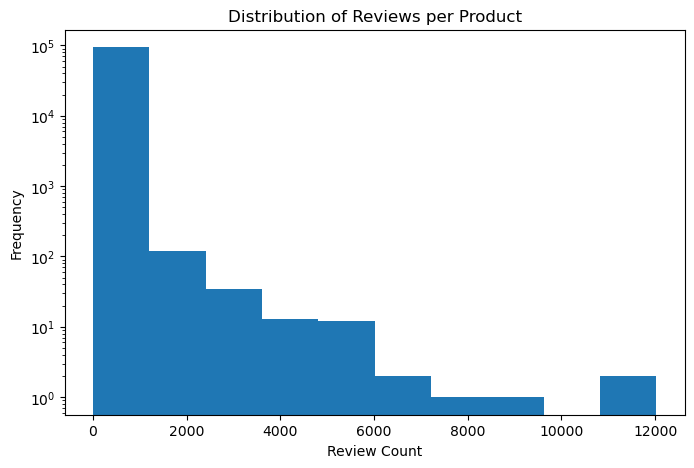

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
# sns.histplot(df_counts["review_count"], bins=50, log_scale=True)
plt.hist(review_counts["review_count"])
plt.title("Distribution of Reviews per Product")
plt.xlabel("Review Count")
plt.yscale('log')
plt.ylabel("Frequency (log scale)")
plt.show()

#### Distribution of Length of Reviews

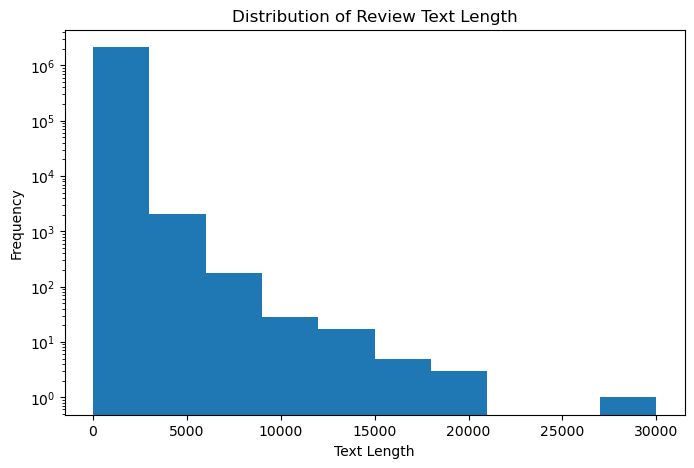

,text_len
0,0
1,0
2,0
3,0
4,0
...,...
2128600,16627
2128601,18632
2128602,19371
2128603,19401


In [39]:
text_length = c2.execute(f"""
    SELECT LENGTH(text) AS text_len
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    WHERE text IS NOT NULL
    ORDER BY text_len
""").df()

plt.figure(figsize=(8, 5))
plt.hist(text_length["text_len"])
plt.title("Distribution of Review Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()
text_length

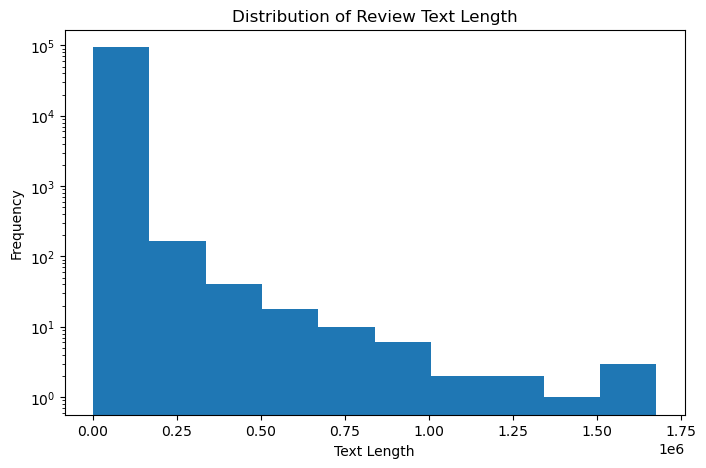

,parent_asin,total_text_size
0,B07RNJY499,1678364.0
1,B01ALBMIEI,1644603.0
2,B09YC8YCV6,1615904.0
3,B07YF9SGBW,1434920.0
4,B000DLB2FI,1314090.0
...,...,...
94314,B0B95WY68X,1.0
94315,B09VT4THJV,1.0
94316,B092T359CX,1.0
94317,B09B32274P,1.0


In [43]:
total_text_length = c2.execute(f"""
    SELECT 
        parent_asin,
        SUM(LENGTH(text)) AS total_text_size
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY parent_asin
    ORDER BY total_text_size DESC
""").df()

plt.figure(figsize=(8, 5))
plt.hist(total_text_length["total_text_size"])
plt.title("Distribution of Review Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()
total_text_length

#### Duplicate Reviews

In [44]:
c2.execute(f"""
    SELECT 
        text,
        COUNT(*) as cnt
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY text
    HAVING cnt > 1
    ORDER BY cnt DESC
""").df()

,text,cnt
0,Works great,5244
1,Good,4678
2,Easy to install,4672
3,Great,4318
4,Perfect,3622
...,...,...
47276,Yep.,2
47277,Perfect replacement for my filter,2
47278,Nice looking. Easy to install.,2
47279,Easy to change filter.,2


#### Missing Values

In [ ]:
c2.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE product_title IS NULL) AS missing_product_title,
        COUNT(*) FILTER (WHERE text IS NULL) AS missing_text,
        COUNT(*) FILTER (WHERE main_category IS NULL) AS missing_category,
        COUNT(*) FILTER (WHERE store IS NULL) AS missing_store,
        COUNT(*) FILTER (WHERE price IS NULL) AS missing_price
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
""").df()

,missing_product_title,missing_text,missing_category,missing_store,missing_price
0,0,0,28494,6064,528346


### Build Document for each product

In [65]:
print(merged_data.columns)

Index(['rating', 'title', 'text', 'parent_asin', 'helpful_vote',
       'product_title', 'price', 'average_rating', 'main_category', 'store'],
      dtype='str')


#### Group reviews by products

In [66]:
products = c2.execute(f"""
    SELECT 
        parent_asin,
        ANY_VALUE(product_title) AS product_title,
        ANY_VALUE(main_category) AS main_category,
        ANY_VALUE(store) AS store,
        ANY_VALUE(price) AS price,
        ANY_VALUE(average_rating) AS avg_rating,
        LIST(text) AS reviews,
        LIST(title) AS review_titles,
        LIST(helpful_vote) AS helpful_votes
    FROM read_parquet('{PROCESSED_DATA_DIR}/{merged_data_file}')
    GROUP BY parent_asin;
""").df()
products

,parent_asin,product_title,main_category,store,price,avg_rating,reviews,review_titles,helpful_votes
0,B0007INM5A,"Ecopad, the Refillable Coffee Filter for the C...",Amazon Home,Coffeeduck,NaN,4.0,"[VERY GOOD, These work well with the Hamilton ...","[Three Stars, Very happy with them, A pain to ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, ..."
1,B09M47JJYC,Sesama Reusable Coffee Capsule Vertuo Pod Stai...,Amazon Home,Sesama,NaN,2.5,[Never never buy this item doesn't work what m...,[I used today for the first time didn't work. ...,"[1, 1, 2]"
2,B0794XT868,Enterpark DC31-00076A Replacement Washer Rotor...,Tools & Home Improvement,Enterpark only,29.70,4.2,[It worked perfect with our samsung washing ma...,"[Good product, Solved my problem..., Fast deli...","[0, 1, 0]"
3,B00W1W2DFA,ICEPURE UKF8001 Compatible with Whirlpool EDR4...,Tools & Home Improvement,ICEPURE,27.99,4.7,[great buy when compared to local store prices...,"[Five Stars, Get the correct part, it’s alrigh...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
4,B07VFQ438P,New Star Foodservice 28812 Commercial Grade St...,Amazon Home,New Star Foodservice,11.97,4.7,"[Great price, Well made froth cup for $10. See...","[Perfect size, Satisfied, but...., Five Stars,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
...,...,...,...,...,...,...,...,...,...
94314,B0093RC25C,GE WB27X10932 Thermostat,Tools & Home Improvement,GE,NaN,2.5,[shipping was prompt.....excellent product],[excellent],[0]
94315,B072YSSZTW,Whirlpool 4451042 Thermal,Tools & Home Improvement,Whirlpool,NaN,4.4,[I did some searching on the probable reason w...,[Worked Perfectly],[0]
94316,B003FWF4BK,Broan-NuTone Broan 153623 Silhouette Insert wi...,Appliances,Broan-NuTone,NaN,4.8,[Thanks],[Five Stars],[0]
94317,B00K0LMB7E,AP4024680 NEW FACTORY ORIGINAL OEM MAYTAG CLOT...,Tools & Home Improvement,Whirlpool,NaN,2.0,[wrong item],[Two Stars],[0]


#### Preprocessing Reviews then add to document
- ignore short meaning less reviews
- truncate reviews by number of characters
- only include top reviews ranked by `helpful_vote`
- remove duplicated reviews

In [110]:
def build_document(product, max_reviews=20, min_len=30, max_chars=None):
    reviews = product['reviews']
    review_titles = product['review_titles']
    helpful_votes = product['helpful_votes']

    # Combine and sort reviews by helpful votes in descending order
    combined = list(zip(helpful_votes, review_titles, reviews))
    combined = sorted(combined, key=lambda x: x[0] if x[0] is not None else 0, reverse=True)

    review_lines = []
    logged_review = []
    for vote, title, review in combined:
        # filter short reviews
        if not review or len(review) < min_len:
            continue
        
        review = review[:max_chars]  # truncate long reviews
        
        # remove duplicate reviews
        if review not in logged_review:
            review_lines.append(f"- ({vote} votes) {title}: {review}")
            logged_review.append(review)
        
        # limit number of reviews
        if len(review_lines) >= max_reviews:
            break

    review_block = "\n".join(review_lines)

    doc = f"""
Title: {product.get('product_title', '')} {product.get('product_title', '')}
Category: {product.get('main_category', '')}
Store: {product.get('store', '')}
Price: {product.get('price', '')}
Average Rating: {product.get('avg_rating', '')}

Reviews:
{review_block}
""".strip()

    return doc


In [112]:
print(build_document(products.loc[0]))

Title: Ecopad, the Refillable Coffee Filter for the Classic Senseo (pack of 2) Ecopad, the Refillable Coffee Filter for the Classic Senseo (pack of 2)
Category: Amazon Home
Store: Coffeeduck
Price: nan
Average Rating: 4.0

Reviews:
- (361 votes) Ecopads Rule!!  Excellent, consistent,  and very durable!.: I bought my Senseo machine over 2 years ago (when they first came out) as an alternative to splurging on a much pricier machine after my mediocre Krups espresso maker died.  While I loved the Senseo concept, I was disapointed with the coffee, even when I used the pods I bought from supposedly Gourmet suppliers, and considered spending the bucks on a true pump espresso machine.  THEN I FOUND THE ECOPADS!! While I was a bit skeptical, (at that time they were only available from some obscure website--I think in the Netherlands) I took a chance and paid $13 + shipping for 2 pads.  I loved them.  So I bought two more for when the first two wore out, but the first pair are still going strong

In [86]:
print(build_document(products.loc[10]))

Title: Whirlpool 9743590 Door Seal Replacement Whirlpool 9743590 Door Seal Replacement
Category: Tools & Home Improvement
Store: Whirlpool
Price: 54.63
Average Rating: 4.2

Reviews:
- (0 votes) leak: It didn't stop the leak, but it was easy to replace
- (0 votes) Fixed an old  KitchenAid dishwasher: It worked on our old KitchenAid dishwasher
- (0 votes) Careful in the corners!: As install video noted it is important to be sure the gasket is not bunched as it goes around the corners.  Easily avoided by slight stretching as it is inserted.<br /><br />I first replaced the lower door gasket, then this one. Unfortunately the door still leaks. Don't think it is related to this gasket, but searching for answers.
- (0 votes) Great part: It was the part I needed for my dishwasher and it was easy to install and fixed the problem
- (0 votes) Happy wife. What more can you ask for: Old seal on the 17 year old dishwasher was a bit stiff and water was dribbling out the front. Ordered this replacement